In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load cleaned dataset
df = pd.read_csv("GlobalWeatherRepository_Cleaned.csv")


print(df.shape)
df.head()

(63935, 20)


,country,location_name,latitude,longitude,temperature_celsius,condition_text,wind_kph,pressure_mb,precip_mm,humidity,cloud,feels_like_celsius,visibility_km,uv_index,gust_kph,air_quality_us-epa-index,sunrise,sunset,Year,Month
0,Afghanistan,Kabul,0.571365,0.399381,0.540650,Partly Cloudy,0.036113,0.358491,0.000000,0.216495,0.30,0.494141,0.3125,0.4375,0.042422,0.0,04:50 AM,06:50 PM,2024,5
1,Albania,Tirana,0.685122,0.109307,0.386179,Partly cloudy,0.028295,0.358491,0.003595,0.938144,0.75,0.371094,0.3125,0.3125,0.053662,0.0,05:21 AM,07:54 PM,2024,5
2,Algeria,Algiers,0.608783,0.010754,0.467480,Sunny,0.042815,0.349057,0.000000,0.268041,0.00,0.480469,0.3125,0.3125,0.067803,0.0,05:40 AM,07:50 PM,2024,5
3,Andorra,Andorra La Vella,0.704666,0.001763,0.128049,Light drizzle,0.030901,0.311321,0.010784,0.597938,1.00,0.074219,0.0625,0.1250,0.036621,0.0,06:31 AM,09:11 PM,2024,5
4,Armenia,Yerevan,0.665912,0.254403,0.386179,Partly cloudy,0.011914,0.405660,0.004673,0.381443,0.25,0.371094,0.3125,0.2500,0.022843,0.0,05:45 AM,08:12 PM,2024,5


In [ ]:
# Statistical summary
summary_stats = df.describe()
print(summary_stats)

# Save if needed
summary_stats.to_csv("statistical_summary.csv")

           latitude     longitude  temperature_celsius      wind_kph  \
count  63935.000000  63935.000000         63935.000000  63935.000000   
mean       0.518554      0.267121             0.463092      0.035268   
std        0.278011      0.231822             0.190414      0.030784   
min        0.000000      0.000000             0.000000      0.000000   
25%        0.251141      0.086858             0.327236      0.010797   
50%        0.590909      0.188936             0.497967      0.028295   
75%        0.725267      0.399792             0.597561      0.053611   
max        1.000000      1.000000             1.000000      1.000000   

        pressure_mb     precip_mm      humidity         cloud  \
count  63935.000000  63935.000000  63935.000000  63935.000000   
mean       0.370730      0.004646      0.564403      0.354781   
std        0.069006      0.018382      0.250979      0.342445   
min        0.000000      0.000000      0.000000      0.000000   
25%        0.330189      0

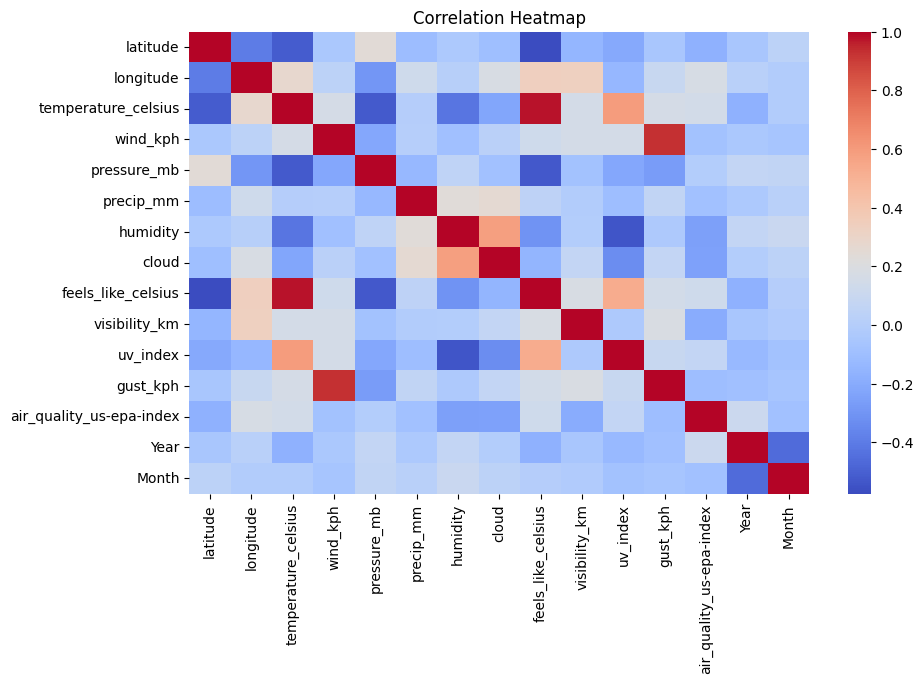

In [ ]:
# Correlation matrix
corr_matrix = df.corr(numeric_only=True)

plt.figure(figsize=(10,6))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

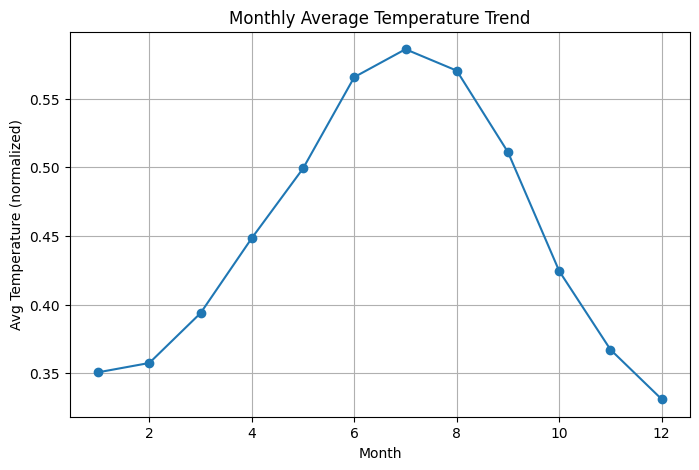

In [ ]:
# Extract month
df['month'] = df['Month']

monthly_temp = df.groupby('month')['temperature_celsius'].mean()

plt.figure(figsize=(8,5))
monthly_temp.plot(marker='o')
plt.title("Monthly Average Temperature Trend")
plt.xlabel("Month")
plt.ylabel("Avg Temperature (normalized)")
plt.grid(True)
plt.show()

In [ ]:
# Thresholds (top/bottom 5%)
high_temp_thresh = df['temperature_celsius'].quantile(0.95)
low_temp_thresh = df['temperature_celsius'].quantile(0.05)
heavy_rain_thresh = df['precip_mm'].quantile(0.95)
high_wind_thresh = df['wind_kph'].quantile(0.95)

extreme_events = df[
    (df['temperature_celsius'] >= high_temp_thresh) |
    (df['temperature_celsius'] <= low_temp_thresh) |
    (df['precip_mm'] >= heavy_rain_thresh) |
    (df['wind_kph'] >= high_wind_thresh)
]

print("Extreme events count:", len(extreme_events))

Extreme events count: 12527


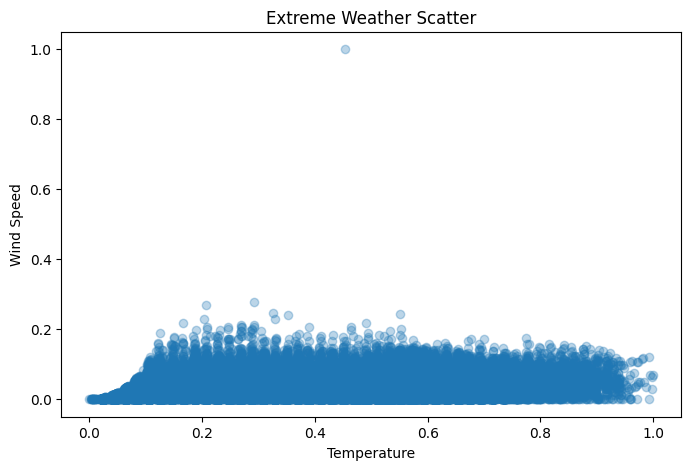

In [ ]:
plt.figure(figsize=(8,5))
plt.scatter(df['temperature_celsius'], df['wind_kph'], alpha=0.3)
plt.title("Extreme Weather Scatter")
plt.xlabel("Temperature")
plt.ylabel("Wind Speed")
plt.show()

In [ ]:
country_stats = df.groupby('country').agg({
    'temperature_celsius':'mean',
    'humidity':'mean',
    'precip_mm':'mean',
    'wind_kph':'mean'
}).reset_index()

print(country_stats.head())

       country  temperature_celsius  humidity  precip_mm  wind_kph
0  Afghanistan             0.419157  0.210825   0.001234  0.019400
1      Albania             0.420901  0.537539   0.005219  0.020005
2      Algeria             0.433916  0.611309   0.001670  0.035384
3      Andorra             0.282772  0.552292   0.004035  0.016456
4      Armenia             0.407349  0.368964   0.001415  0.014688


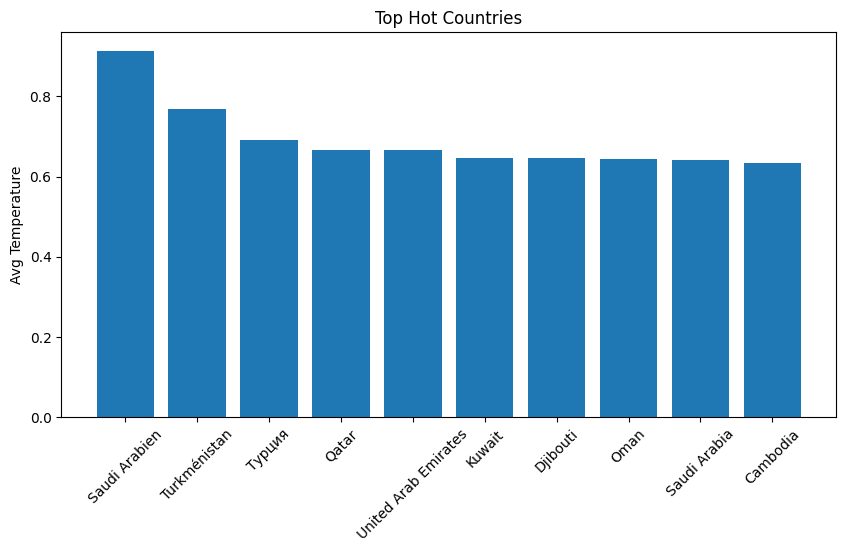

In [ ]:
top_countries = country_stats.sort_values(
    'temperature_celsius', ascending=False
).head(10)

plt.figure(figsize=(10,5))
plt.bar(top_countries['country'], top_countries['temperature_celsius'])
plt.xticks(rotation=45)
plt.title("Top Hot Countries")
plt.ylabel("Avg Temperature")
plt.show()

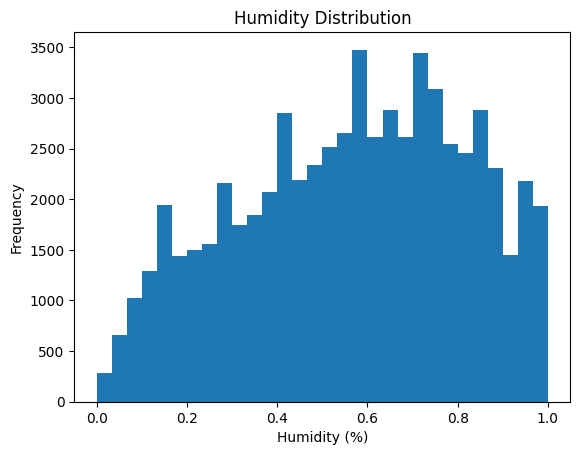

In [ ]:
plt.hist(df['humidity'], bins=30)
plt.title("Humidity Distribution")
plt.xlabel("Humidity (%)")
plt.ylabel("Frequency")
plt.show()

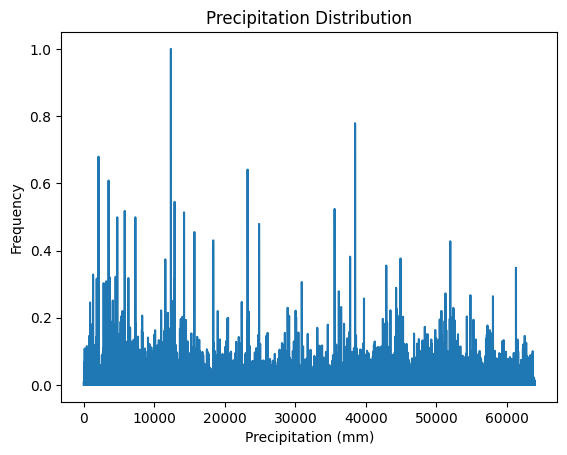

In [ ]:
plt.plot(df['precip_mm'])
plt.title("Precipitation Distribution")
plt.xlabel("Precipitation (mm)")
plt.ylabel("Frequency")
plt.show()

In [ ]:
monthly_data = df.groupby('month').mean(numeric_only=True)
correlation = monthly_data.corr(numeric_only=True)

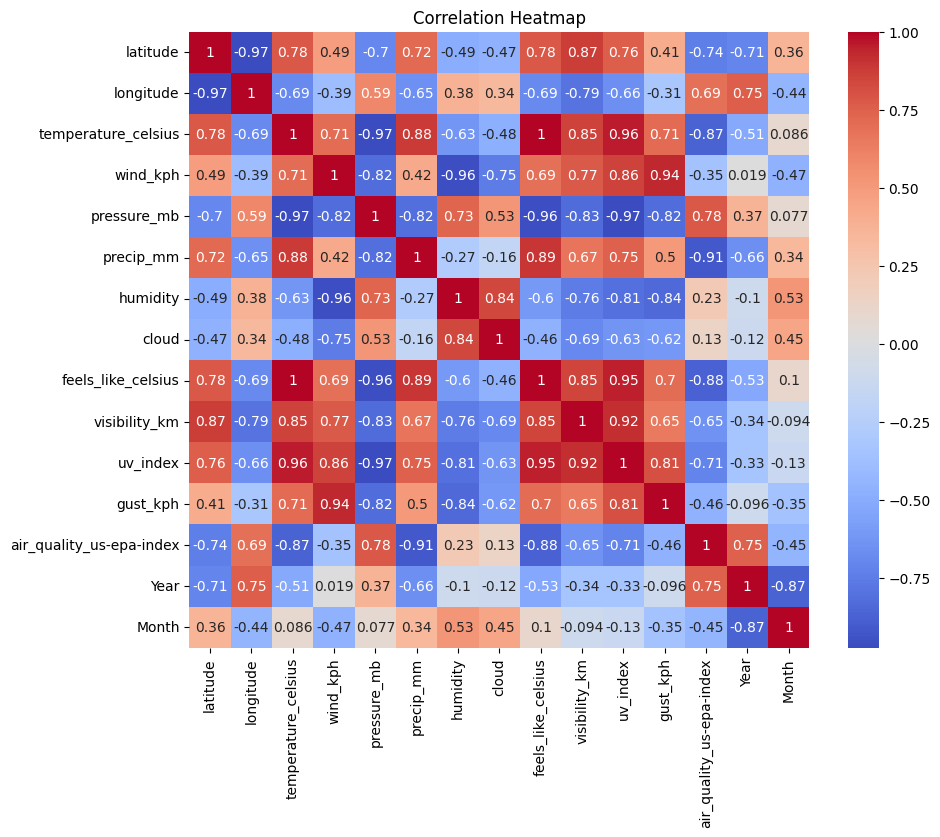

In [ ]:
import seaborn as sns

plt.figure(figsize=(10,8))
sns.heatmap(correlation, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

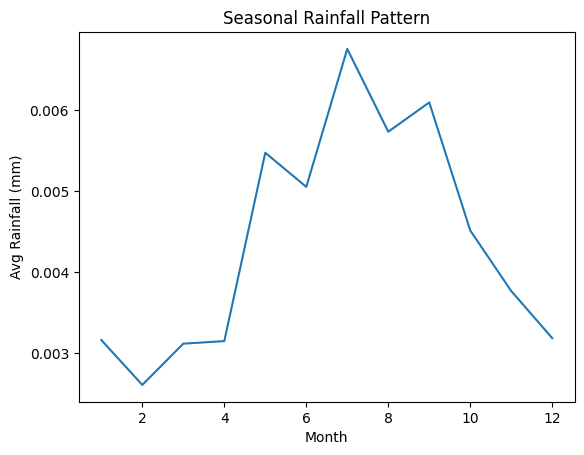

In [ ]:
seasonal_rain = monthly_data.groupby('month')['precip_mm'].mean()

plt.plot(seasonal_rain)
plt.title("Seasonal Rainfall Pattern")
plt.xlabel("Month")
plt.ylabel("Avg Rainfall (mm)")
plt.show()

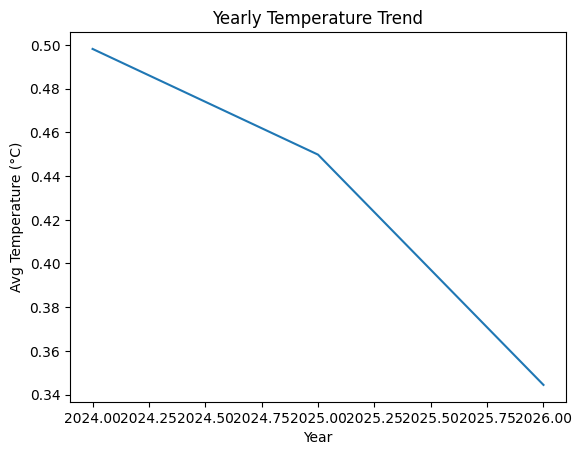

In [ ]:
yearly_trend = df.groupby('Year')['temperature_celsius'].mean()

plt.plot(yearly_trend)
plt.title("Yearly Temperature Trend")
plt.xlabel("Year")
plt.ylabel("Avg Temperature (°C)")
plt.show()

In [ ]:
country_pm25 = df.groupby('country')['air_quality_us-epa-index'].mean().sort_values(ascending=False)

country_pm25.head(10)

,air_quality_us-epa-index
country,
China,0.635816
Südkorea,0.600000
India,0.583544
Saudi Arabia,0.580952
Kuwait,0.536278
Bahrain,0.454574
United Arab Emirates,0.419874
Malaysia,0.416088
Qatar,0.413586


In [ ]:
country_rain = df.groupby('country')['precip_mm'].mean().sort_values(ascending=False)

country_rain.head(10)

,precip_mm
country,
Lao People's Democratic Republic,0.070812
Letonia,0.065780
USA United States of America,0.057153
Malásia,0.055715
Malaysia,0.021050
Brunei Darussalam,0.018701
Nepal,0.017643
Myanmar,0.016368
Sri Lanka,0.016169


Total Extreme Events: 6292


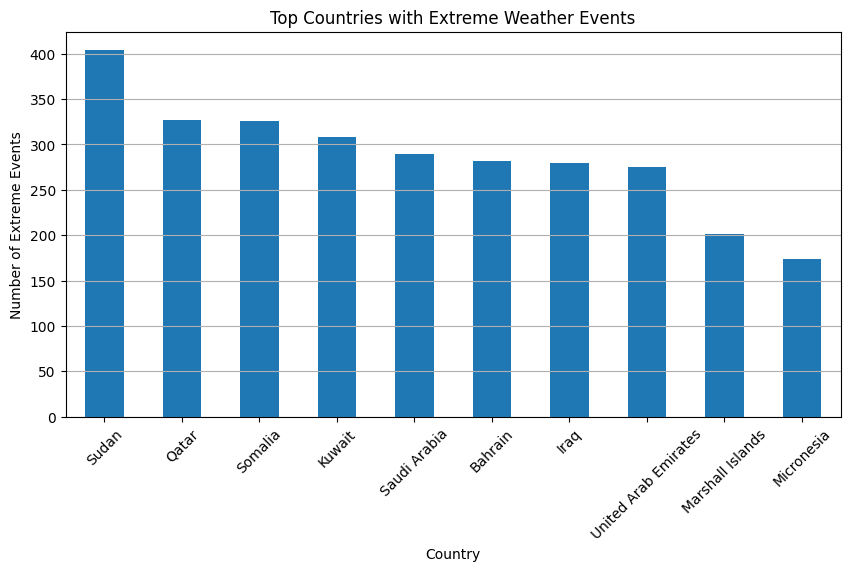

In [ ]:
temp_thresh = df['temperature_celsius'].quantile(0.95)
wind_thresh = df['wind_kph'].quantile(0.95)
extreme_df = df[
    (df['temperature_celsius'] >= temp_thresh) |
    (df['wind_kph'] >= wind_thresh)
]
print("Total Extreme Events:", len(extreme_df))
extreme_country = extreme_df['country'].value_counts().head(10)
plt.figure(figsize=(10,5))
extreme_country.plot(kind='bar')
plt.title("Top Countries with Extreme Weather Events")
plt.xlabel("Country")
plt.ylabel("Number of Extreme Events")
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.show()

In [ ]:
import plotly.express as px
country_temp = df.groupby('country')['temperature_celsius'].mean().reset_index()
fig = px.choropleth(
    country_temp,
    locations='country',
    locationmode='country names',
    color='temperature_celsius',
    color_continuous_scale='RdYlBu_r',
    title='Global Average Temperature by Country'
)

fig.show()

In [ ]:
country_humidity = df.groupby('country')['humidity'].mean().reset_index()

fig = px.choropleth(
    country_humidity,
    locations='country',
    locationmode='country names',
    color='humidity',
    color_continuous_scale='Blues',
    title='Global Average Humidity (Normalized)'
)

fig.show()

In [ ]:
country_wind = df.groupby('country')['wind_kph'].mean().reset_index()

fig = px.choropleth(
    country_wind,
    locations='country',
    locationmode='country names',
    color='wind_kph',
    color_continuous_scale='Viridis',
    title='Global Average Wind Speed (Normalized)'
)

fig.show()

In [ ]:
country_rain = df.groupby('country')['precip_mm'].mean().reset_index()

fig = px.choropleth(
    country_rain,
    locations='country',
    locationmode='country names',
    color='precip_mm',
    color_continuous_scale='PuBu',
    title='Global Average Precipitation (Normalized)'
)

fig.show()

In [ ]:
country_uv = df.groupby('country')['uv_index'].mean().reset_index()

fig = px.choropleth(
    country_uv,
    locations='country',
    locationmode='country names',
    color='uv_index',
    color_continuous_scale='YlOrRd',
    title='Global Average UV Index (Normalized)'
)

fig.show()